# 1.1 Khai báo thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Cấu hình để hiển thị biểu đồ đẹp hơn và bỏ qua cảnh báo
%matplotlib inline
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')

print("Thành công: Đã load các thư viện.")

Thành công: Đã load các thư viện.


# 1.2. Tải tập dữ liệu (Load Dataset)
Dữ liệu được chia thành hai tập chính: 
- `train.csv`: Dùng để huấn luyện mô hình.
- `test.csv`: Dùng để kiểm tra khả năng dự đoán của mô hình.

In [2]:
# Đường dẫn tương đối dựa trên cấu trúc thư mục của bạn
train_path = '../data/raw/train.csv'
test_path = '../data/raw/test.csv'

# Load dữ liệu vào DataFrame
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Kích thước tập Train: {train_df.shape}")
print(f"Kích thước tập Test: {test_df.shape}")

Kích thước tập Train: (140700, 20)
Kích thước tập Test: (93800, 19)


# 1.3. Quan sát dữ liệu sơ bộ
Chúng ta sẽ xem 5 dòng đầu tiên và thông tin chi tiết về các cột (kiểu dữ liệu, giá trị thiếu).

In [3]:
# Xem 5 dòng đầu tiên của tập train
print("5 dòng đầu tiên của dữ liệu")
display(train_df.head())

# Kiểm tra thông tin các cột và kiểu dữ liệu
print("\nThông tin chi tiết các cột")
info_df = pd.DataFrame({
    'Tên cột': train_df.columns,
    'Kiểu dữ liệu': train_df.dtypes.values,
    'Số dòng khác null': train_df.notnull().sum().values,
    'Số dòng null': train_df.isnull().sum().values,
    'Tỷ lệ null (%)': (train_df.isnull().mean().values * 100).round(2)
})

display(info_df)

5 dòng đầu tiên của dữ liệu


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0



Thông tin chi tiết các cột


,Tên cột,Kiểu dữ liệu,Số dòng khác null,Số dòng null,Tỷ lệ null (%)
0,id,int64,140700,0,0.00
1,Name,object,140700,0,0.00
2,Gender,object,140700,0,0.00
3,Age,float64,140700,0,0.00
4,City,object,140700,0,0.00
5,Working Professional or Student,object,140700,0,0.00
6,Profession,object,104070,36630,26.03
7,Academic Pressure,float64,27897,112803,80.17
8,Work Pressure,float64,112782,27918,19.84
9,CGPA,float64,27898,112802,80.17


## 1.4 Tìm hiểu ý nghĩa các thuộc tính 

Việc hiểu rõ ý nghĩa của từng cột giúp chúng ta có cái nhìn sâu sắc hơn về các yếu tố ảnh hưởng đến sức khỏe tâm thần và đưa ra các giả định phân tích chính xác. Dưới đây là mô tả chi tiết các thuộc tính trong bộ dữ liệu:

| Tên cột | Ý nghĩa | Loại dữ liệu |
| :--- | :--- | :--- |
| **ID** | Mã định danh duy nhất cho mỗi cá nhân tham gia khảo sát. | Định danh  |
| **Gender** | Giới tính của người tham gia (Male/Female). | Phân loại  |
| **Age** | Tuổi của người tham gia khảo sát. | Số  |
| **City** | Thành phố nơi người tham gia đang sinh sống. | Phân loại |
| **Working Professional or Student** | Phân loại đối tượng là Người đi làm hay Sinh viên. | Phân loại  |
| **Profession** | Nghề nghiệp cụ thể của người tham gia. | Phân loại  |
| **Academic Pressure** | Áp lực học tập (thang điểm từ 1 - 5). | Số/Thứ tự  |
| **Work Pressure** | Áp lực công việc (thang điểm từ 1 - 5). | Số/Thứ tự  |
| **CGPA** | Điểm trung bình tích lũy (dành cho sinh viên). | Số  |
| **Study Satisfaction** | Mức độ hài lòng với việc học (thang điểm từ 1 - 5). | Số/Thứ tự (Ordinal) |
| **Job Satisfaction** | Mức độ hài lòng với công việc (thang điểm từ 1 - 5). | Số/Thứ tự |
| **Sleep Duration** | Thời gian ngủ trung bình mỗi ngày (theo nhóm hoặc số giờ). | Phân loại/Số |
| **Dietary Habits** | Thói quen ăn uống. | Phân loại |
| **Degree** | Bằng cấp cao nhất mà người tham gia đạt được. | Phân loại |
| **Have you ever had suicidal thoughts ?** | Đã từng có ý định tự tử hay chưa. | Nhị phân |
| **Work/Study Hours** | Số giờ làm việc hoặc học tập mỗi ngày. | Số  |
| **Financial Stress** | Mức độ áp lực về tài chính (thang điểm từ 1 - 5). | Số/Thứ tự |
| **Family History of Mental Illness** | Tiền sử gia đình có người mắc bệnh tâm thần. | Nhị phân |
| **Depression (Target)** | **Biến mục tiêu: Người đó có bị trầm cảm hay không (1: Có / 0: Không).** | **Nhị phân** |

---

## 2. Thống kê mô tả và kiểm tra dữ liệu 

Trước khi đi sâu vào trực quan hóa, chúng ta cần quan sát các chỉ số thống kê trung gian để:
1. Xác định giá trị trung bình, độ lệch chuẩn, khoảng giá trị Min-Max.
2. Kiểm tra thang điểm của **CGPA** để đưa ra nhận xét chính xác.
3. Nhận diện sơ bộ các biến có khả năng chứa giá trị ngoại lai.

In [4]:
# 1. In kết quả thống kê cho các biến số
print("Thống kê mô tả các biến số")
display(train_df.describe())

# 2. In kết quả thống kê cho các biến phân loại 
print("\nThống kê mô tả các biến phân loại")
display(train_df.describe(include=['O']))

# 3. Kiểm tra cụ thể thang điểm CGPA
cgpa_min = train_df['CGPA'].min()
cgpa_max = train_df['CGPA'].max()
print(f"\n[Kiểm tra thang đo] CGPA: Min = {cgpa_min}, Max = {cgpa_max}")

if cgpa_max <= 4.0:
    print("=> Nhận xét: Dữ liệu CGPA đang sử dụng thang điểm 4.")
elif cgpa_max <= 10.0:
    print("=> Nhận xét: Dữ liệu CGPA đang sử dụng thang điểm 10.")
else:
    print("=> Nhận xét: CGPA có giá trị bất thường -> cần xử lý outliers.")

Thống kê mô tả các biến số


,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,140700.000000,140700.000000,27897.000000,112782.000000,27898.000000,27897.000000,112790.000000,140700.000000,140696.000000,140700.000000
mean,70349.500000,40.388621,3.142273,2.998998,7.658636,2.944940,2.974404,6.252679,2.988983,0.181713
std,40616.735775,12.384099,1.380457,1.405771,1.464466,1.360197,1.416078,3.853615,1.413633,0.385609
min,0.000000,18.000000,1.000000,1.000000,5.030000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,35174.750000,29.000000,2.000000,2.000000,6.290000,2.000000,2.000000,3.000000,2.000000,0.000000
50%,70349.500000,42.000000,3.000000,3.000000,7.770000,3.000000,3.000000,6.000000,3.000000,0.000000
75%,105524.250000,51.000000,4.000000,4.000000,8.920000,4.000000,4.000000,10.000000,4.000000,0.000000
max,140699.000000,60.000000,5.000000,5.000000,10.000000,5.000000,5.000000,12.000000,5.000000,1.000000



Thống kê mô tả các biến phân loại


,Name,Gender,City,Working Professional or Student,Profession,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Family History of Mental Illness
count,140700,140700,140700,140700,104070,140700,140696,140698,140700,140700
unique,422,2,98,2,64,36,23,115,2,2
top,Rohan,Male,Kalyan,Working Professional,Teacher,Less than 5 hours,Moderate,Class 12,No,No
freq,3178,77464,6591,112799,24906,38784,49705,14729,71138,70758



[Kiểm tra thang đo] CGPA: Min = 5.03, Max = 10.0
=> Nhận xét: Dữ liệu CGPA đang sử dụng thang điểm 10.


## 3. Phân tích đơn biến 

Giai đoạn này tập trung vào việc hiểu đặc điểm của từng thuộc tính quan trọng nhất. Chúng ta chia làm 3 nhóm chính:
1. **Biến mục tiêu (`Depression`):** Kiểm tra sự cân bằng dữ liệu.
2. **Nhóm Nhân khẩu học (`Age`, `Gender`):** Xác định đối tượng khảo sát.
3. **Nhóm Học tập/Nghề nghiệp & Lối sống (`CGPA`, `Sleep Duration`,...):** Tìm hiểu các yếu tố tác động tiềm năng.

Mục tiêu là phát hiện các giá trị ngoại lai, dữ liệu nhiễu và hiểu quy mô của từng biến.

In [5]:
def plot_categorical(column, title):
    """Vẽ biểu đồ cột kèm phần trăm (%) cho biến phân loại"""
    plt.figure(figsize=(9, 5))
    ax = sns.countplot(x=column, data=train_df, palette='viridis')
    plt.title(title, fontsize=14, fontweight='bold')
    
    total = len(train_df[column])
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height() + (total * 0.005)
        ax.annotate(percentage, (x, y), ha='center', fontsize=11, fontweight='bold')
    plt.xticks(rotation=45)
    plt.show()

def plot_numerical(column, title):
    """Vẽ Histogram kèm đường Mean/Median và Boxplot cho biến số"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # Histogram
    sns.histplot(train_df[column].dropna(), kde=True, ax=ax1, color='skyblue')
    mean_val = train_df[column].mean()
    median_val = train_df[column].median()
    ax1.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    ax1.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
    ax1.set_title(f'Phân phối của {title}', fontsize=12)
    ax1.legend()
    
    # Boxplot
    sns.boxplot(x=train_df[column], ax=ax2, color='lightcoral')
    ax2.set_title(f'Kiểm tra Outliers của {title}', fontsize=12)
    
    plt.tight_layout()
    plt.show()

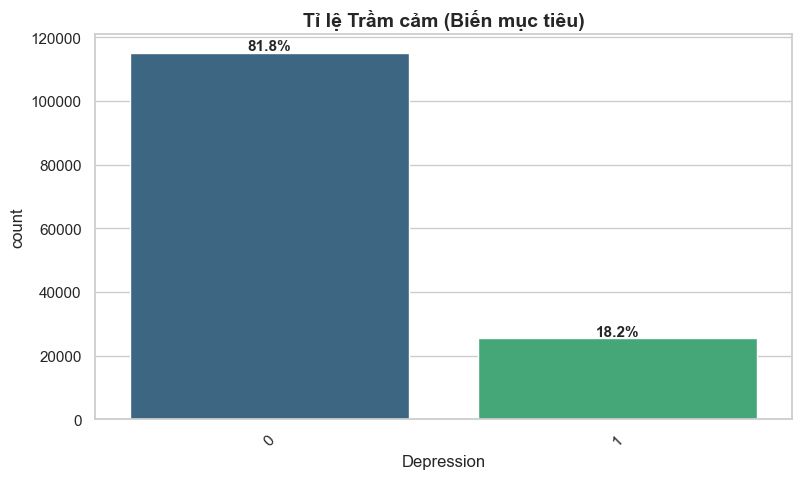

In [6]:
# 1. Biến mục tiêu: Depression
plot_categorical('Depression', 'Tỉ lệ Trầm cảm (Biến mục tiêu)')


---

### **Nhận xét: Phân tích biến mục tiêu (Depression)**

**1. Chỉ số thống kê:**
*   **Tỉ lệ không bị trầm cảm (0):** 81.8% (chiếm đa số tuyệt đối).
*   **Tỉ lệ có bị trầm cảm (1):** 18.2%.

**2. Quan sát và đánh giá:**
*   **Mất cân bằng dữ liệu:** Bộ dữ liệu cho thấy sự chênh lệch đáng kể giữa hai lớp. Số người không bị trầm cảm cao gấp khoảng 4.5 lần số người bị trầm cảm. Đây là một đặc điểm phổ biến trong các tập dữ liệu về y tế hoặc khảo sát sức khỏe tâm thần, khi tỉ lệ người mắc bệnh thường chiếm thiểu số.
*   **Độ đại diện:** Mặc dù bị lệch, nhưng con số 18.2% (khoảng hơn 20,000 mẫu) vẫn là một lượng dữ liệu đủ lớn để mô hình máy học có thể học được các đặc điểm của nhóm người bị trầm cảm.

**3. Ảnh hưởng và hướng xử lý cho các bước tiếp theo:**
*   **Về lựa chọn chỉ số đánh giá:** Do dữ liệu bị mất cân bằng, chúng ta **không nên chỉ sử dụng độ chính xác (Accuracy)** để đánh giá mô hình. Nếu một mô hình dự đoán tất cả mọi người đều "Không trầm cảm", nó vẫn đạt được độ chính xác 81.8% nhưng hoàn toàn vô dụng. Vì vậy, nhóm sẽ tập trung vào các chỉ số như **F1-Score, Precision, Recall và AUC-ROC** để đảm bảo mô hình nhận diện tốt nhóm người bị trầm cảm (lớp 1).
*   **Về kỹ thuật huấn luyện:** Trong bước xây dựng mô hình, nhóm có thể cân nhắc các kỹ thuật xử lý mất cân bằng như:
    *   Sử dụng trọng số cho các lớp.
    *   Kỹ thuật lấy mẫu lại (Oversampling - SMOTE hoặc Undersampling).

---



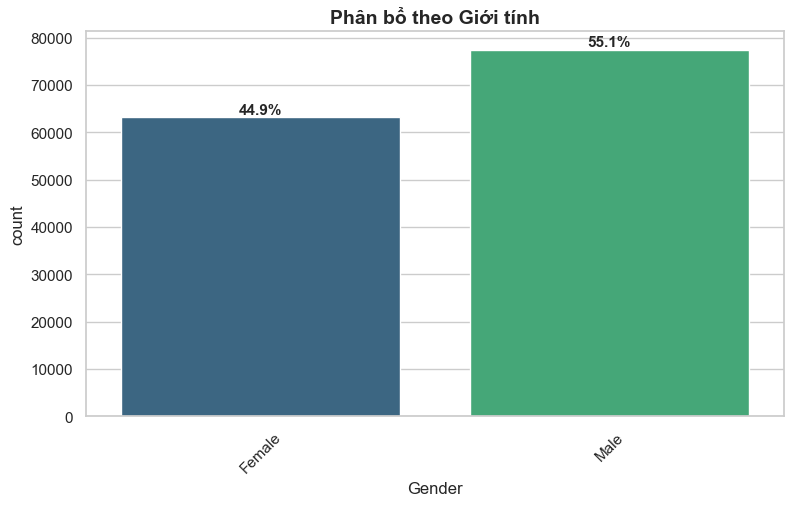

In [7]:

# 2. Giới tính (Gender)
plot_categorical('Gender', 'Phân bổ theo Giới tính')


Ta thấy giới tính trong tập dữ liệu phân bổ bình thường. Cho thấy sự công bằng giữa nam và nữ, giúp tránh đưa ra kết luận bị bias về một phía

---

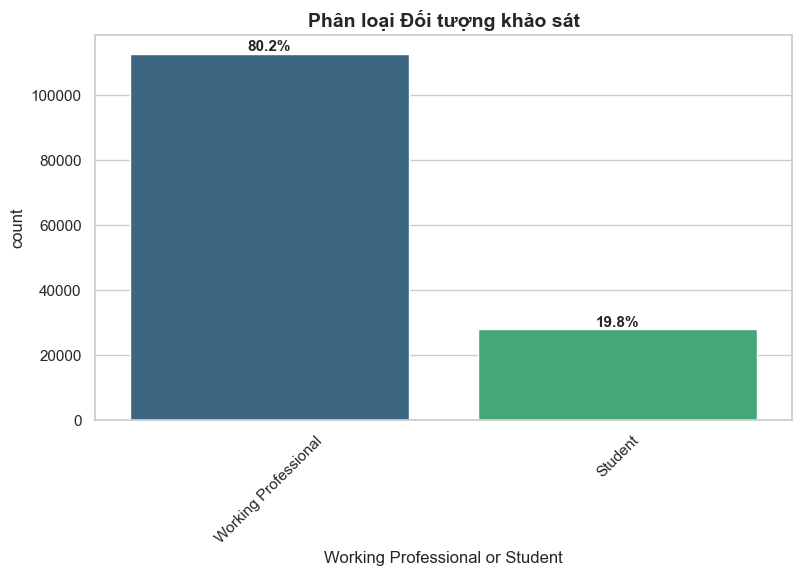

In [8]:
# 4. Phân loại Đối tượng
plot_categorical('Working Professional or Student', 'Phân loại Đối tượng khảo sát')




**Nhận xét:**
*   **Cơ cấu đối tượng:** Có sự chênh lệch lớn về thành phần tham gia, trong đó **người đi làm (Working Professional)** chiếm đa số tuyệt đối với **80.2%**, gấp khoảng 4 lần so với **sinh viên (19.8%)**.
*   **Đánh giá:** Tập dữ liệu tập trung chủ yếu vào nhóm đối tượng lao động. Do đó, các đặc trưng liên quan đến môi trường làm việc (Work Pressure, Job Satisfaction) dự kiến sẽ có tác động lớn hơn đến mô hình so với các biến về học tập.

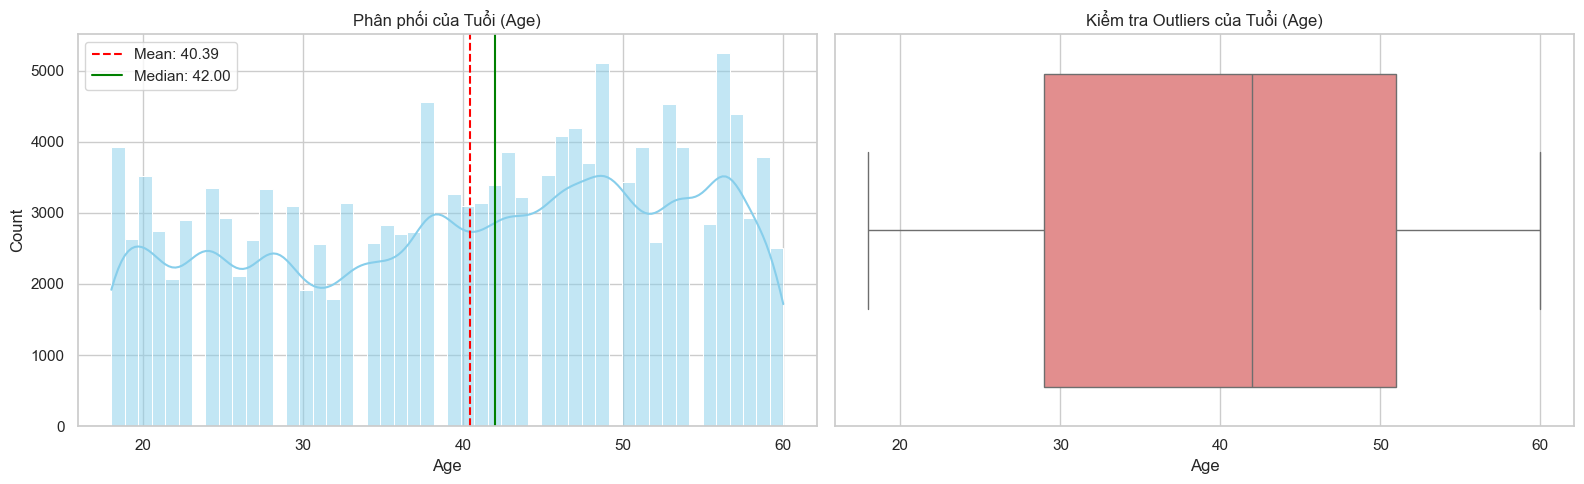

In [9]:
# 3. Tuổi (Age)
plot_numerical('Age', 'Tuổi (Age)')


---

### **Nhận xét: Phân tích biến tuổi (Age)**

**1. Chỉ số thống kê cơ bản:**
*   **Phạm vi:** Tuổi của đối tượng khảo sát trải dài từ **18 đến 60 tuổi**. Đây là khoảng tuổi hợp lý, bao quát cả nhóm sinh viên và người đi làm.
*   **Giá trị trung bình:** 40.39 tuổi.
*   **Trung vị:** 42.00 tuổi.

**2. Hình dáng phân phối:**
*   **Phân phối đa đỉnh:** Biểu đồ Histogram cho thấy nhiều đỉnh nhấp nhô, dữ liệu không tập trung vào một nhóm tuổi nhất định mà rải khá đều từ trẻ đến trung niên.
*   **Độ lệch:** Giá trị Median (42.00) lớn hơn Mean (40.39) một chút, cho thấy dữ liệu có xu hướng **lệch trái nhẹ**. Tuy nhiên, sự chênh lệch này không quá lớn, dữ liệu vẫn đảm bảo độ đa dạng về tuổi tác.

**3. Kiểm tra giá trị ngoại lai:**
*   **Kết quả:** Biểu đồ Boxplot cho thấy **không có giá trị ngoại lai** nào xuất hiện.
*   **Đánh giá:** Dữ liệu cột tuổi rất sạch và nằm hoàn toàn trong ngưỡng sinh học bình thường của đối tượng lao động và học tập.

**4. Ý nghĩa đối với bài toán trầm cảm:**
*   **Độ bao phủ:** Việc dữ liệu trải dài từ 18 đến 60 giúp mô hình có khả năng học được sự ảnh hưởng của trầm cảm ở các giai đoạn cuộc đời khác nhau:
    *   **Nhóm trẻ (18-25):** Thường gắn liền với áp lực học tập (Academic Pressure).
    *   **Nhóm trung niên (30-60):** Thường gắn liền với áp lực công việc (Work Pressure) và tài chính (Financial Stress).
*   **Tiền xử lý:** Vì không có giá trị ngoại lai và khoảng giá trị không quá lớn (18-60), chúng ta có thể sử dụng trực tiếp biến này hoặc thực hiện chuẩn hóa để đưa về cùng thang đo với các biến số khác khi huấn luyện mô hình.

---



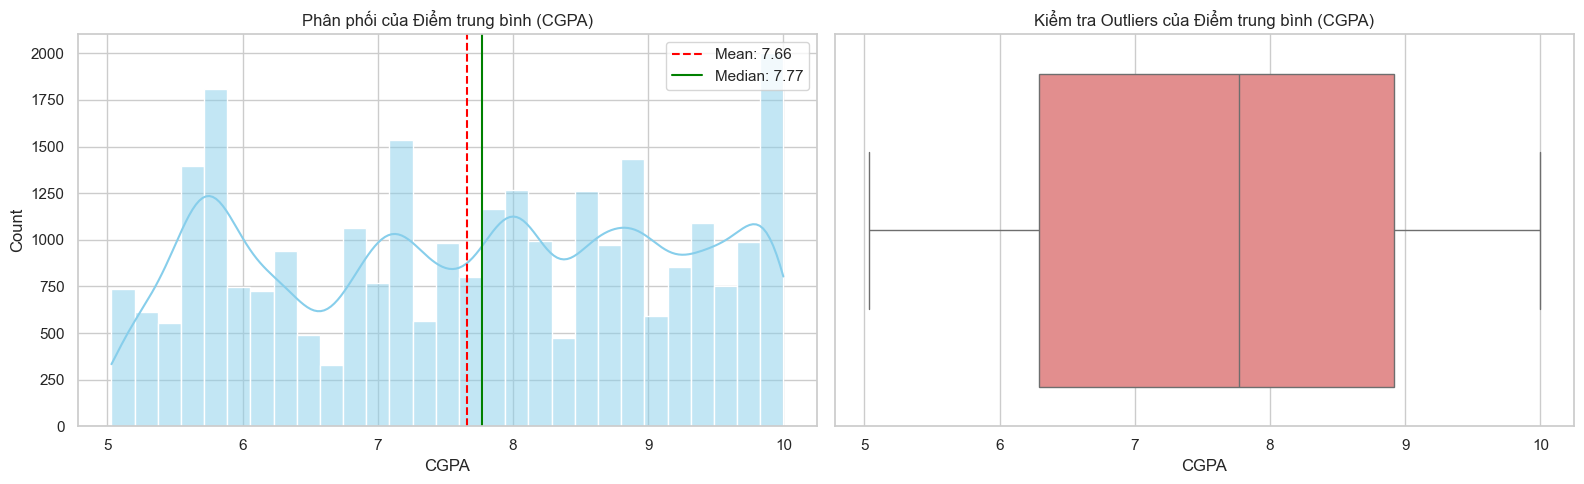

In [10]:

# 5. Điểm trung bình (CGPA) - Cần chú ý thang điểm
plot_numerical('CGPA', 'Điểm trung bình (CGPA)')





**Nhận xét:**
*   **Thang điểm:** Dữ liệu CGPA nằm trong khoảng từ **5.0 đến 10.0**, cho thấy khảo sát đang sử dụng **thang điểm 10**.
*   **Phân phối:** Biểu đồ có dạng **đa đỉnh (multimodal)**, với các cụm điểm tập trung nhiều ở mức 5.5-6.0, 7.5 và đặc biệt tăng cao ở mức 10.0. Giá trị Median (7.77) cao hơn Mean (7.66) cho thấy dữ liệu lệch trái nhẹ.
*   **Giá trị ngoại lai:** Biểu đồ Boxplot xác nhận **không có giá trị ngoại lai**.
*   **Kết luận:** Dữ liệu sạch, phản ánh sự đa dạng về năng lực học tập của nhóm đối tượng sinh viên/người đi làm trong tập dữ liệu.

# 4. Phân tích đa biến 

Sau khi hiểu đặc điểm từng biến, chúng ta sẽ phân tích mối quan hệ giữa chúng để tìm ra các yếu tố then chốt dẫn đến Trầm cảm.
- **Ma trận tương quan:** Xem xét mối liên hệ tuyến tính giữa các biến số.
- **Phân tích biến phân loại vs. Depression:** Tìm hiểu nhóm đối tượng nào có tỉ lệ trầm cảm cao hơn.
- **Phân tích biến số vs. Depression:** Xem sự thay đổi của các chỉ số (Tuổi, Điểm số) ảnh hưởng thế nào đến khả năng bị trầm cảm.

## Ma trận tương quan giữa các biến số 

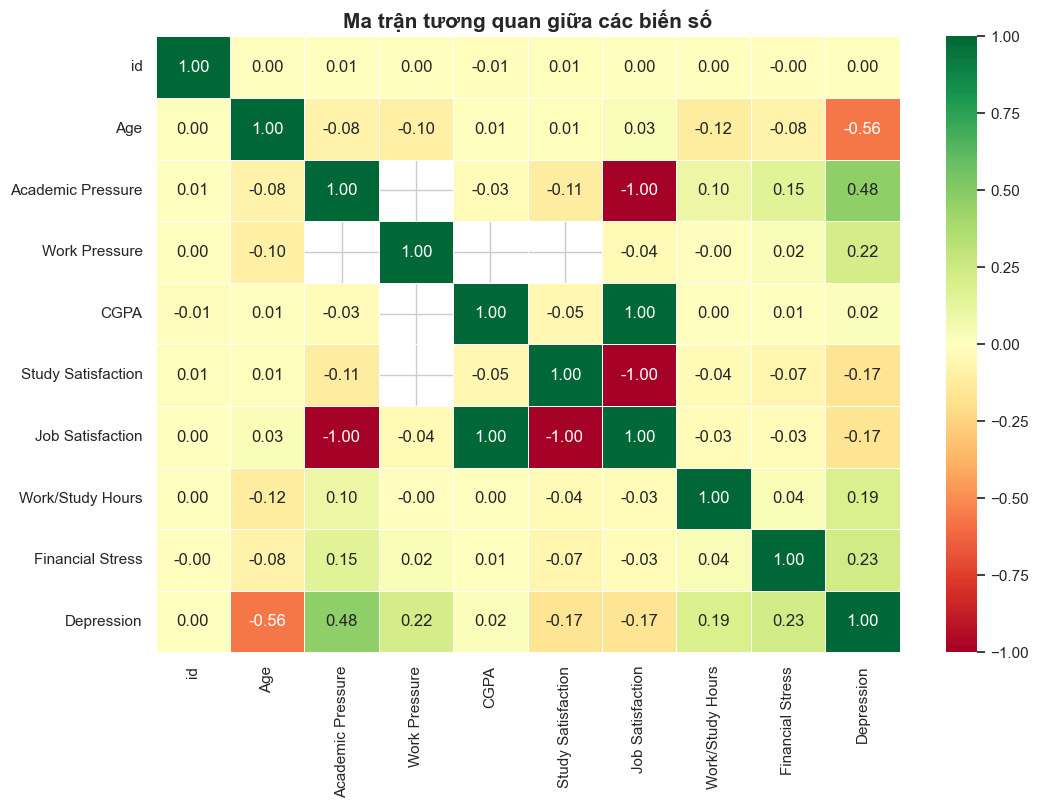

In [11]:
plt.figure(figsize=(12, 8))

# Tính toán ma trận tương quan cho các cột dữ liệu số
# Lưu ý: Depression là 0/1 nên cũng được tính như một biến số ở đây
numeric_df = train_df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Vẽ Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số', fontsize=15, fontweight='bold')
plt.show()



### **Nhận xét: Phân tích ma trận tương quan**

**1. Các yếu tố tương quan mạnh nhất với trầm cảm (Depression):**
*   **Tuổi (Age) và Depression (-0.56):** Đây là mối **tương quan nghịch** mạnh nhất. Điều này cho thấy trong tập dữ liệu này, những người ở độ tuổi trẻ hơn có xu hướng có tỉ lệ trầm cảm cao hơn. Đây là một biến quan trọng cho mô hình dự đoán.
*   **Áp lực học tập (Academic Pressure) và Depression (0.48):** Mối **tương quan thuận** khá mạnh. Áp lực học tập càng tăng thì khả năng bị trầm cảm càng cao.
*   **Áp lực tài chính (Financial Stress) và Depression (0.23):** Có tương quan thuận nhưng ở mức độ yếu hơn so với áp lực học tập.

**2. Các yếu tố có tương quan yếu hoặc không đáng kể:**
*   **CGPA (0.02) và Work/Study Hours (0.19):** Điểm số (CGPA) hầu như không có mối liên hệ trực tiếp nào với tình trạng trầm cảm trong tập dữ liệu này. Thời gian làm việc/học tập cũng chỉ có tác động rất nhẹ.
*   **ID (0.00):** Cột ID hoàn toàn không có tương quan, điều này đúng với thực tế vì ID chỉ là mã định danh.

**3. Phát hiện điểm bất thường:**
Ma trận xuất hiện các cặp tương quan **tuyệt đối (1.00 hoặc -1.00)** giữa các biến khác nhau, đây là một dấu hiệu rất lạ trong dữ liệu thực tế:
*   **Job Satisfaction vs. CGPA (1.00):** Tương quan thuận tuyệt đối.
*   **Job Satisfaction vs. Academic Pressure (-1.00):** Tương quan nghịch tuyệt đối.
*   **Job Satisfaction vs. Study Satisfaction (-1.00):** Tương quan nghịch tuyệt đối.

**=> Đánh giá kỹ thuật:** Những con số 1.00 và -1.00 này cho thấy các biến này có mối quan hệ tuyến tính hoàn hảo với nhau. Điều này thường xảy ra trong **dữ liệu giả lập** hoặc do cách thu thập dữ liệu có quy luật cứng nhắc. 
*   **Hệ quả:** Khi xây dựng mô hình, nhóm cần cẩn trọng với hiện tượng **đa cộng tuyến**. Nếu giữ tất cả các biến này, mô hình (đặc biệt là Logistic Regression) có thể bị nhiễu. Nhóm nên cân nhắc loại bỏ bớt một trong các biến có tương quan tuyệt đối này trong bước Feature Selection.

**4. Kết luận cho bước tiếp theo:**
*   **Biến quan trọng:** `Age`, `Academic Pressure`, `Financial Stress`, và `Work Pressure` là những đặc trưng hàng đầu nên đưa vào mô hình.
*   **Xử lý dữ liệu:** Cần xem xét kỹ lại các biến có tương quan 1.00/-1.00 trước khi thực hiện huấn luyện để đảm bảo độ tin cậy của mô hình.

---



## Tỉ lệ Trầm cảm theo các nhóm thuộc tính

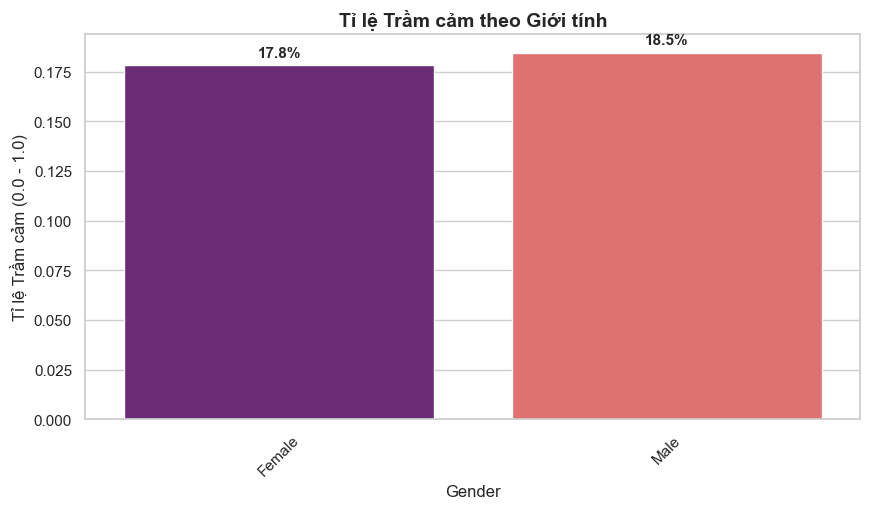

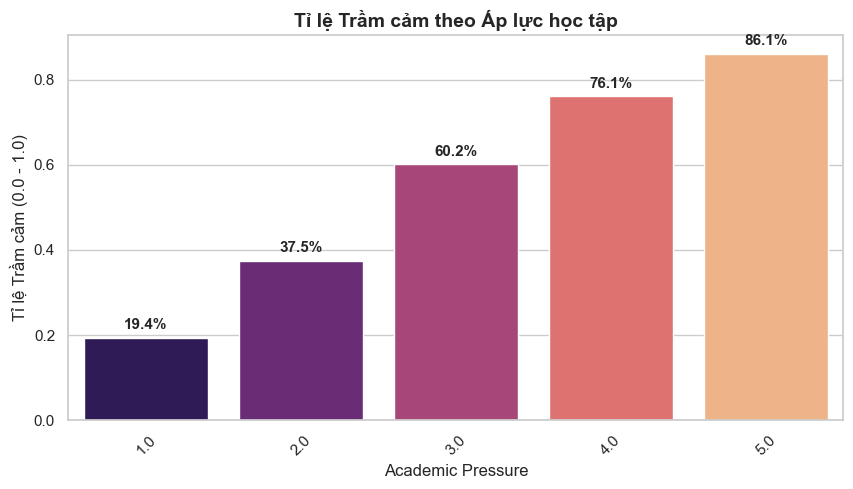

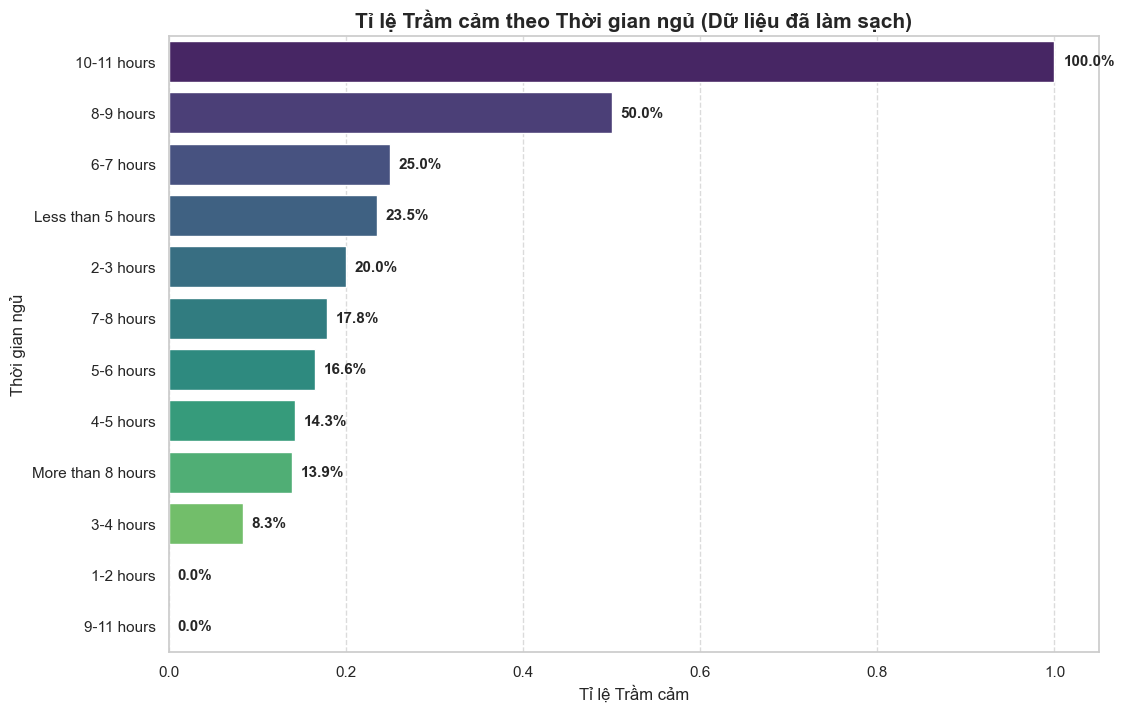

In [12]:
def plot_depression_rate(column, title):
    plt.figure(figsize=(10, 5))
    # Barplot tự động tính giá trị trung bình (tỉ lệ 1 / tổng), tức là tỉ lệ Trầm cảm
    ax = sns.barplot(x=column, y='Depression', data=train_df, palette='magma', ci=None)
    
    plt.title(f'Tỉ lệ Trầm cảm theo {title}', fontsize=14, fontweight='bold')
    plt.ylabel('Tỉ lệ Trầm cảm (0.0 - 1.0)')
    
    # Thêm nhãn % trên đầu cột
    for p in ax.patches:
        ax.annotate(f'{p.get_height()*100:.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=11, fontweight='bold')
    plt.xticks(rotation=45)
    plt.show()

# 1. Tỉ lệ Trầm cảm theo Giới tính
plot_depression_rate('Gender', 'Giới tính')

# 2. Tỉ lệ Trầm cảm theo Áp lực học tập (Academic Pressure)
plot_depression_rate('Academic Pressure', 'Áp lực học tập')

# 3. Tỉ lệ Trầm cảm theo Thời gian ngủ
# 1. Xác định các giá trị hợp lệ cho thời gian ngủ
# Chúng ta chỉ giữ lại những giá trị thực sự nói về giờ giấc
valid_sleep_categories = [
    'Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours',
    '1-2 hours', '2-3 hours', '3-4 hours', '4-5 hours', '5-6 hours', 
    '6-7 hours', '7-8 hours', '8-9 hours', '9-11 hours', '10-11 hours'
]

# Tạo một bản mẫu dữ liệu sạch chỉ chứa các giá trị hợp lệ
clean_sleep_df = train_df[train_df['Sleep Duration'].isin(valid_sleep_categories)]

# 2. Vẽ biểu đồ cột ngang để dễ đọc nhãn
plt.figure(figsize=(12, 8))

# Tính tỉ lệ trầm cảm và sắp xếp theo thứ tự giảm dần 
sleep_order = clean_sleep_df.groupby('Sleep Duration')['Depression'].mean().sort_values(ascending=False).index

ax = sns.barplot(
    y='Sleep Duration', 
    x='Depression', 
    data=clean_sleep_df, 
    palette='viridis', 
    order=sleep_order,
    ci=None
)

# 3. Thêm phần trăm vào cuối mỗi thanh
for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + 0.01, 
        p.get_y() + p.get_height()/2, 
        f'{width*100:.1f}%', 
        va='center', 
        fontsize=11, 
        fontweight='bold'
    )

plt.title('Tỉ lệ Trầm cảm theo Thời gian ngủ (Dữ liệu đã làm sạch)', fontsize=15, fontweight='bold')
plt.xlabel('Tỉ lệ Trầm cảm', fontsize=12)
plt.ylabel('Thời gian ngủ', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


---

### 1. Nhận xét: Tỉ lệ trầm cảm theo giới tính (Gender)

*   **Số liệu quan sát:** Tỉ lệ trầm cảm ở **Nữ giới (Female)** là **17.8%** và ở **Nam giới (Male)** là **18.5%**.
*   **Phân tích:** 
    *   Sự chênh lệch về tỉ lệ trầm cảm giữa hai giới tính là rất nhỏ (chỉ **0.7%**). 
    *   Điều này cho thấy trong tập dữ liệu này, giới tính không phải là một yếu tố phân loại mạnh mẽ để dự đoán tình trạng trầm cảm. Cả nam và nữ đều có xác suất gặp phải các vấn đề sức khỏe tâm thần tương đương nhau.
*   **Kết luận kỹ thuật:** Biến `Gender` có thể không mang lại nhiều giá trị đóng góp cao cho mô hình dự đoán nếu đứng độc lập.

### 2. Nhận xét: Tỉ lệ Trầm cảm theo áp lực học tập (Academic Pressure)

*   **Số liệu quan sát:** Tỉ lệ trầm cảm tăng đều và mạnh theo mức độ áp lực:
    *   Mức 1.0 (Thấp nhất): **19.4%**
    *   Mức 5.0 (Cao nhất): **86.1%**
*   **Phân tích:** 
    *   Biểu đồ cho thấy một mối quan hệ **tỉ lệ thuận tuyến tính** cực kỳ rõ rệt. Khi áp lực học tập tăng lên, tỉ lệ người bị trầm cảm cũng tăng theo tỉ lệ tương ứng.
    *   Đáng chú ý, ở mức áp lực cao nhất (5.0), có đến hơn 86% đối tượng tham gia khảo sát bị trầm cảm. Đây là một con số báo động.
*   **Kết luận kỹ thuật:** `Academic Pressure` chắc chắn là một trong những **biến đặc trưng quan trọng nhất**. Mô hình máy học nên tập trung khai thác biến này để đạt độ chính xác cao.

### 3. Nhận xét: Tỉ lệ trầm cảm theo thời gian ngủ (Sleep Duration)

*   **Số liệu quan sát:**
    *   Tỉ lệ trầm cảm cao nhất ở nhóm ngủ **10-11 hours (100%)** và **8-9 hours (50%)**.
    *   Nhóm ngủ đủ giấc tiêu chuẩn (**7-8 hours**) hoặc hơi thiếu ngủ (**5-6 hours**) có tỉ lệ trầm cảm khá thấp, dao động từ **16.6% đến 17.8%**.
    *   Nhóm ngủ rất ít (**1-2 hours**) hoặc nhóm ngủ dài (**9-11 hours**) lại có tỉ lệ là **0%**.
*   **Phân tích & Cảnh báo dữ liệu:** 
    *   Có sự bất thường trong dữ liệu: Việc nhóm ngủ 10-11 giờ có tỉ lệ trầm cảm 100% và một số nhóm khác 0% có thể là do **kích thước mẫu quá nhỏ** ở những nhóm này (ví dụ chỉ có 1-2 người rơi vào nhóm đó).
    *   Tuy nhiên, nhìn chung, sự thay đổi thời gian ngủ có tác động lớn đến tâm lý. Ngủ quá nhiều hoặc ngủ quá ít so với mức trung bình đều cho thấy những dấu hiệu bất ổn về sức khỏe tâm thần.
*   **Kết luận kỹ thuật:** Cần cẩn trọng khi đưa biến này vào mô hình. Nhóm nên thực hiện gom nhóm các giá trị thời gian ngủ hoặc xử lý các nhóm có mẫu quá ít để tránh mô hình bị overfitting vào các giá trị 100% hoặc 0% này.

---



## Phân tích sự phân bổ của biến số theo trầm cảm 

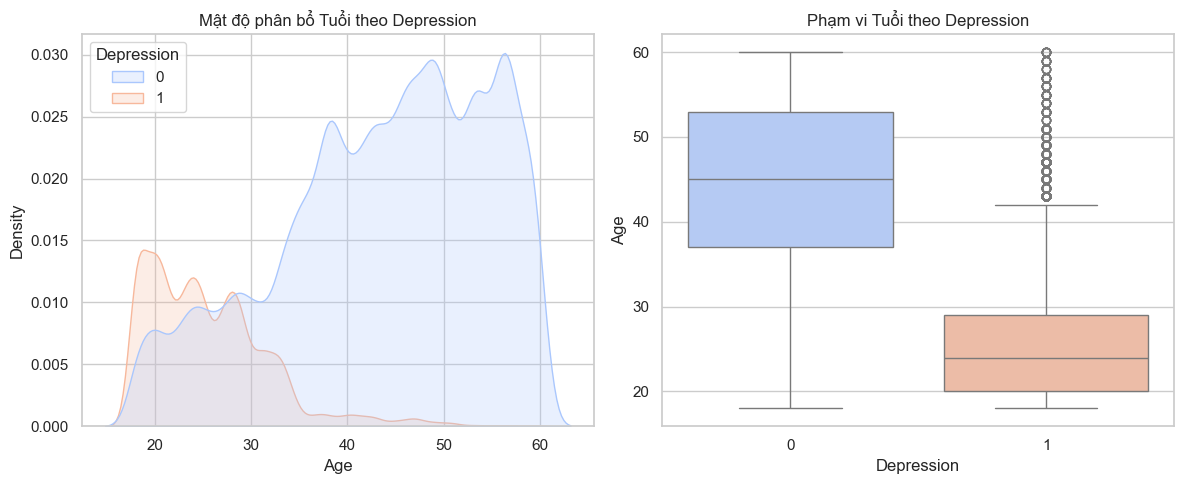

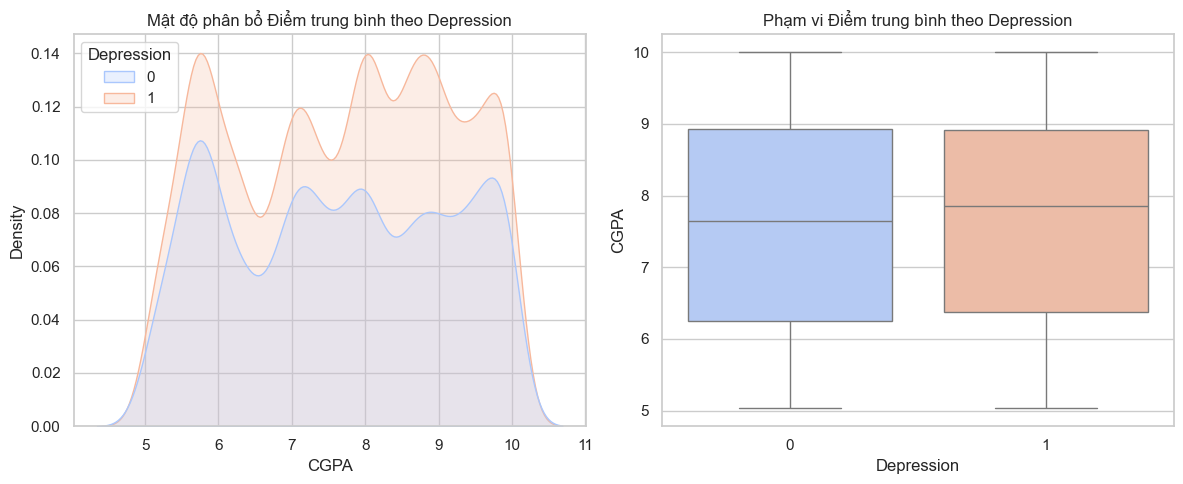

In [13]:
def plot_numeric_vs_target(column, title):
    plt.figure(figsize=(12, 5))
    
    # KDE Plot (Biểu đồ mật độ)
    plt.subplot(1, 2, 1)
    sns.kdeplot(data=train_df, x=column, hue='Depression', shade=True, palette='coolwarm')
    plt.title(f'Mật độ phân bổ {title} theo Depression')
    
    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x='Depression', y=column, data=train_df, palette='coolwarm')
    plt.title(f'Phạm vi {title} theo Depression')
    
    plt.tight_layout()
    plt.show()

# Phân tích Tuổi và CGPA đối với Trầm cảm
plot_numeric_vs_target('Age', 'Tuổi')
plot_numeric_vs_target('CGPA', 'Điểm trung bình')



---

### 1. Nhận xét: Mối quan hệ giữa Tuổi (Age) và Trầm cảm

*   **Quan sát từ biểu đồ KDE:**
    *   Có một sự **phân hóa rõ rệt** giữa hai nhóm. Nhóm người bị trầm cảm (màu cam) tập trung cực kỳ đông đảo ở độ tuổi trẻ, đỉnh điểm là khoảng **18 - 30 tuổi**.
    *   Ngược lại, nhóm không bị trầm cảm (màu xanh) lại chiếm ưu thế ở độ tuổi trung niên, từ **35 - 60 tuổi**.
*   **Quan sát từ biểu đồ Boxplot:**
    *   **Trung vị:** Nhóm bị trầm cảm có độ tuổi trung bình rất thấp (khoảng **24 tuổi**), trong khi nhóm không bị trầm cảm có trung vị lên tới khoảng **45 tuổi**.
    *   **Giá trị ngoại lai:** Ở cột `Depression = 1`, xuất hiện rất nhiều giá trị ngoại lai kéo dài từ 42 đến 60 tuổi. Điều này cho thấy mặc dù đa số người trầm cảm là người trẻ, nhưng vẫn có một bộ phận nhỏ người lớn tuổi gặp tình trạng này.
*   **Kết luận:** **Tuổi tác là một biến dự báo cực kỳ mạnh mẽ.** Mô hình có thể dễ dàng phân loại dựa trên độ tuổi (người càng trẻ xác suất trầm cảm càng cao trong tập dữ liệu này).

### 2. Nhận xét: Mối quan hệ giữa Điểm trung bình (CGPA) và Trầm cảm

*   **Quan sát từ biểu đồ KDE:**
    *   Đường cong của nhóm 0 (xanh) và nhóm 1 (cam) **gần như chồng khít lên nhau**. Cả hai đều có các đỉnh tương đồng tại các mốc điểm 5.5, 7.5 và 10.0.
    *   Điều này cho thấy mật độ phân bổ điểm số của người bị trầm cảm và người bình thường là tương đương nhau.
*   **Quan sát từ biểu đồ Boxplot:**
    *   Hình dáng hộp và vị trí các đường trung vị của hai nhóm là **gần như y hệt nhau** (xấp xỉ mức 7.7 - 7.8 điểm).
    *   Không có sự khác biệt đáng kể về phạm vi điểm số giữa người bị trầm cảm và người không bị.
*   **Kết luận:** **CGPA có khả năng dự báo rất yếu.** Nhìn vào biểu đồ này, ta thấy điểm số cao hay thấp không thực sự quyết định việc một người có bị trầm cảm hay không. Đây là một phát hiện thú vị, cho thấy các yếu tố khác (như áp lực, tuổi tác) có tầm ảnh hưởng lớn hơn kết quả học tập thuần túy.

---

### Insight tổng kết 

1.  **Biến quan trọng nhất:** Qua phân tích đa biến này, **Age** nổi lên là đặc trưng hàng đầu cần được chú trọng khi xây dựng mô hình.
2.  **Sự tương phản:** Có một sự đối lập thú vị: trong khi **ap lực học tập (Academic Pressure)** liên quan rất chặt chẽ đến trầm cảm, thì **Kết quả học tập thực tế (CGPA)** lại không cho thấy sự liên quan rõ rệt. Điều này ngụ ý rằng cảm giác bị áp lực có hại cho sức khỏe tâm thần hơn là con số điểm số thật sự.
3.  **Hướng xử lý:** Với biến `Age`, vì có sự phân hóa mạnh, chúng ta có thể cân nhắc việc chia nhóm tuổi như: "Thanh niên", "Trung niên" để mô hình học tốt hơn.



---
# 5. Tiền xử lý dữ liệu 

Dựa trên các phát hiện từ bước EDA, chúng ta tiến hành các bước chuẩn bị dữ liệu sau:
- Loại bỏ các cột không mang giá trị dự báo (`id`).
- Xử lý giá trị thiếu (Imputation).
- Chuẩn hóa các giá trị nhiễu ở cột `Sleep Duration`.

## 5.1. Loại bỏ cột không cần thiết và xử lý giá trị thiếu

In [14]:
# 1. Loại bỏ cột ID (vì nó chỉ là số thứ tự)
train_df = train_df.drop(columns=['id'], errors='ignore')
test_df = test_df.drop(columns=['id'], errors='ignore')

# 2. Kiểm tra giá trị thiếu
print("Số lượng giá trị thiếu trong tập Train:")
print(train_df.isnull().sum())

# 3. Xử lý giá trị thiếu: 
# - Với biến số: Điền bằng trung vị để tránh bị ảnh hưởng bởi outliers
# - Với biến phân loại: Điền bằng giá trị xuất hiện nhiều nhất 
# 1. Loại bỏ cột ID 
if 'id' in train_df.columns:
    train_df = train_df.drop(columns=['id'])
if 'id' in test_df.columns:
    test_df = test_df.drop(columns=['id'])

# 2. Xử lý giá trị thiếu
for col in train_df.columns:
    # Lấy giá trị để điền 
    if train_df[col].dtype == 'object':
        fill_value = train_df[col].mode()[0]
    else:
        fill_value = train_df[col].median()
    
    # Điền cho tập Train
    train_df[col] = train_df[col].fillna(fill_value)
    
    # Chỉ điền cho tập Test nếu cột đó có tồn tại trong Test 
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(fill_value)

print("Đã xử lý xong giá trị thiếu")
print(f"Giá trị thiếu còn lại trong Train: {train_df.isnull().sum().sum()}")
print(f"Giá trị thiếu còn lại trong Test: {test_df.isnull().sum().sum()}")


Số lượng giá trị thiếu trong tập Train:
Name                                          0
Gender                                        0
Age                                           0
City                                          0
Working Professional or Student               0
Profession                                36630
Academic Pressure                        112803
Work Pressure                             27918
CGPA                                     112802
Study Satisfaction                       112803
Job Satisfaction                          27910
Sleep Duration                                0
Dietary Habits                                4
Degree                                        2
Have you ever had suicidal thoughts ?         0
Work/Study Hours                              0
Financial Stress                              4
Family History of Mental Illness              0
Depression                                    0
dtype: int64
Đã xử lý xong giá trị thiếu
Giá trị

## 5.2. Nhận diện và xử lí nhiễu 

### 5.2.1. Nhận diện nhiễu trong các biến số 

Các biến số sẽ được kiểm tra: ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']
[Age]
  IQR = 22.000  |  Fence: [-4.000, 84.000]
  Số outlier: 0  (0.00%)

[Academic Pressure]
  IQR = 0.000  |  Fence: [3.000, 3.000]
  Số outlier: 20434  (14.52%)

[Work Pressure]
  IQR = 2.000  |  Fence: [-1.000, 7.000]
  Số outlier: 0  (0.00%)

[CGPA]
  IQR = 0.000  |  Fence: [7.770, 7.770]
  Số outlier: 27629  (19.64%)

[Study Satisfaction]
  IQR = 0.000  |  Fence: [3.000, 3.000]
  Số outlier: 22074  (15.69%)

[Job Satisfaction]
  IQR = 2.000  |  Fence: [-1.000, 7.000]
  Số outlier: 0  (0.00%)

[Work/Study Hours]
  IQR = 7.000  |  Fence: [-7.500, 20.500]
  Số outlier: 0  (0.00%)

[Financial Stress]
  IQR = 2.000  |  Fence: [-1.000, 7.000]
  Số outlier: 0  (0.00%)

BẢNG TỔNG HỢP KẾT QUẢ IQR


,Cột,Q1,Q3,IQR,Lower fence,Upper fence,Số outlier,Tỉ lệ (%)
0,Age,29.00,51.00,22.0,-4.00,84.00,0,0.00
1,Academic Pressure,3.00,3.00,0.0,3.00,3.00,20434,14.52
2,Work Pressure,2.00,4.00,2.0,-1.00,7.00,0,0.00
3,CGPA,7.77,7.77,0.0,7.77,7.77,27629,19.64
4,Study Satisfaction,3.00,3.00,0.0,3.00,3.00,22074,15.69
5,Job Satisfaction,2.00,4.00,2.0,-1.00,7.00,0,0.00
6,Work/Study Hours,3.00,10.00,7.0,-7.50,20.50,0,0.00
7,Financial Stress,2.00,4.00,2.0,-1.00,7.00,0,0.00



Vẽ biểu đồ cho 3 cột có nhiễu: ['Academic Pressure', 'CGPA', 'Study Satisfaction']


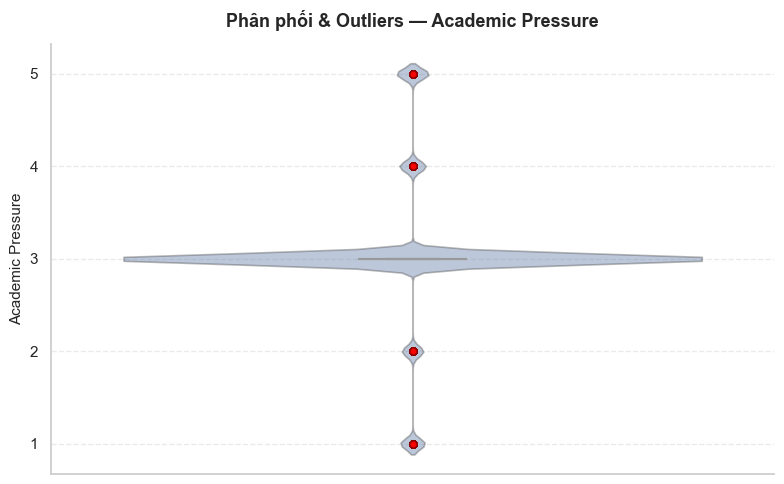

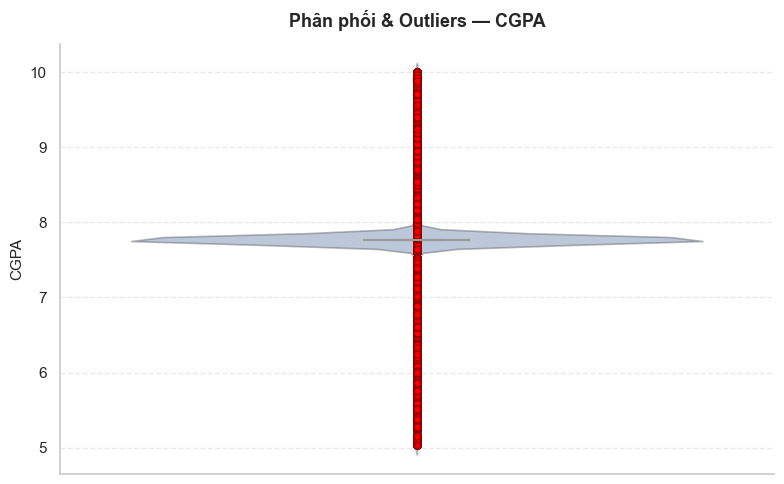

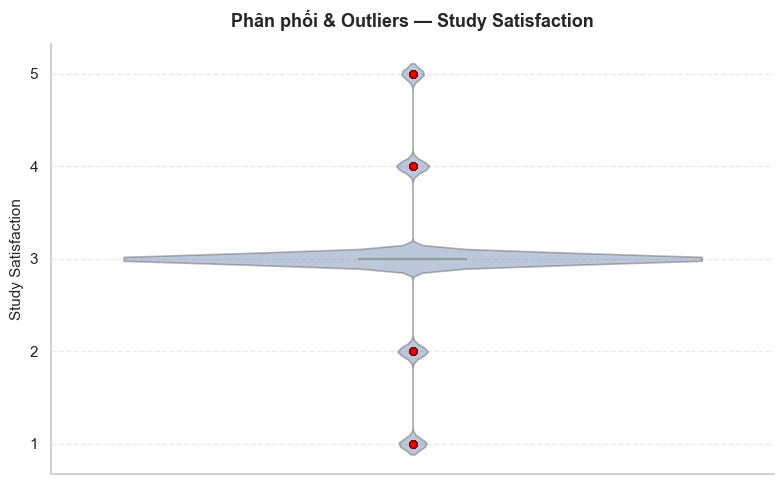

In [22]:
# Phát hiện nhiễu (outliers) trong các biến số bằng phương pháp IQR

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

# Loại bỏ biến mục tiêu (Depression là 0/1, không xét outlier)
numeric_cols = [c for c in numeric_cols if c != 'Depression']

print("Các biến số sẽ được kiểm tra:", numeric_cols)

outlier_summary = []

for col in numeric_cols:
    series = train_df[col].dropna()
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers     = series[(series < lower) | (series > upper)]
    n_outliers   = len(outliers)
    pct_outliers = n_outliers / len(series) * 100

    outlier_summary.append({
        'Cột': col,
        'Q1': round(Q1, 3), 'Q3': round(Q3, 3), 'IQR': round(IQR, 3),
        'Lower fence': round(lower, 3), 'Upper fence': round(upper, 3),
        'Số outlier': n_outliers,
        'Tỉ lệ (%)': round(pct_outliers, 2),
    })

    print(f"[{col}]")
    print(f"  IQR = {IQR:.3f}  |  Fence: [{lower:.3f}, {upper:.3f}]")
    print(f"  Số outlier: {n_outliers}  ({pct_outliers:.2f}%)")
    print()

# Bảng tổng hợp
print("BẢNG TỔNG HỢP KẾT QUẢ IQR")
df_summary = pd.DataFrame(outlier_summary)
display(df_summary)

# Vẽ biểu đồ chỉ các cột CÓ outlier
noisy_cols = [r['Cột'] for r in outlier_summary if r['Số outlier'] > 0]

if not noisy_cols:
    print("\nKhông có biến số nào chứa outlier theo ngưỡng IQR 1.5×.")
else:
    print(f"\nVẽ biểu đồ cho {len(noisy_cols)} cột có nhiễu: {noisy_cols}")
    for col in noisy_cols:
        series = train_df[col].dropna()

        fig, ax = plt.subplots(figsize=(8, 5))

        sns.violinplot(
            y=series,
            ax=ax,
            color='#4C72B0',
            alpha=0.4,
            inner=None,
            linewidth=1.2
        )

        sns.boxplot(
            y=series,
            ax=ax,
            width=0.15,
            color='white',
            linewidth=1.5,
            flierprops=dict(
                marker='o',
                markerfacecolor='red',
                markeredgecolor='darkred',
                markersize=5,
                alpha=0.7,
                linestyle='none'
            )
        )

        ax.set_title(f'Phân phối & Outliers — {col}', fontsize=13, fontweight='bold', pad=12)
        ax.set_ylabel(col, fontsize=11)
        ax.set_xlabel('')
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        sns.despine()

        plt.tight_layout()
        plt.show()

### Nhận xét: Kết quả phát hiện nhiễu trong các biến số

Áp dụng phương pháp **IQR (1.5 × IQR)**, kết quả cho thấy:

- **`Age`, `Work Pressure`, `Job Satisfaction`, `Work/Study Hours`, `Financial Stress`**: Không phát hiện outlier. Phân phối nằm trong khoảng hợp lý.

- **`Academic Pressure`, `Study Satisfaction`, `CGPA`**: IQR = 0 — đây là **hệ quả trực tiếp của bước điền giá trị thiếu bằng median** ở phần 5.1. Hàng nghìn giá trị bị điền cùng một giá trị trung vị khiến phân phối tập trung đột biến tại một điểm, làm IQR co về 0. Khi đó fence = median, và mọi giá trị khác đều bị gắn nhãn outlier — đây là **artifact của quá trình imputation**, không phải nhiễu thực sự trong dữ liệu gốc.

> **Kết luận:** Không thực hiện xử lý outlier cho bất kỳ biến số nào. Các giá trị bị phát hiện đều nằm trong phạm vi hợp lệ của thang đo và không ảnh hưởng tiêu cực đến mô hình.

### 5.2.2: Chuẩn hóa nhãn không hợp lệ trong biến phân loại `Sleep Duration`

Cột `Sleep Duration` chứa các nhãn dạng chuỗi mô tả khoảng thời gian ngủ. Qua EDA, phát hiện một số giá trị không hợp lệ (nhập sai định dạng, khoảng trắng thừa, hoặc nhãn không thuộc danh sách chuẩn). Ta thực hiện chuẩn hóa bằng cách thay thế các giá trị không hợp lệ bằng **mode** của các giá trị hợp lệ.

In [16]:
valid = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours',
         '1-2 hours', '2-3 hours', '3-4 hours', '4-5 hours', '6-7 hours',
         '8-9 hours', '9-11 hours', '10-11 hours']

sleep_mode = train_df.loc[
    train_df['Sleep Duration'].isin(valid),
    'Sleep Duration'
].mode()[0]

def clean_sleep_duration(value):
    value = str(value).strip()
    
    if value in valid:
        return value
    
    return sleep_mode

train_df['Sleep Duration'] = train_df['Sleep Duration'].apply(clean_sleep_duration)
test_df['Sleep Duration'] = test_df['Sleep Duration'].apply(clean_sleep_duration)

print("Mode của Sleep Duration:", sleep_mode)
print("Các giá trị Sleep Duration sau khi làm sạch:")
print(train_df['Sleep Duration'].unique())

Mode của Sleep Duration: Less than 5 hours
Các giá trị Sleep Duration sau khi làm sạch:
['More than 8 hours' 'Less than 5 hours' '5-6 hours' '7-8 hours'
 '1-2 hours' '6-7 hours' '10-11 hours' '8-9 hours' '9-11 hours'
 '2-3 hours' '3-4 hours' '4-5 hours']


## Lưu dữ liệu đã tiền xử lý

In [17]:
processed_dir = '../data/processed'

if not os.path.exists(processed_dir):
    os.makedirs(processed_dir)

train_df.to_csv('../data/processed/train_cleaned.csv', index=False)
test_df.to_csv('../data/processed/test_cleaned.csv', index=False)

print("Đã lưu vào ../data/processed/")

Đã lưu vào ../data/processed/
